<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/svm_non_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import files
filename=files.upload()

Saving disease_prediction_dataset_yes_no.csv to disease_prediction_dataset_yes_no.csv


In [3]:
import io
fil=next(iter(filename))
df=pd.read_csv(io.StringIO(filename[fil].decode('utf-8')))
df.head()

,Age,Blood_Pressure,Cholesterol,Glucose_Level,BMI,Heart_Rate,Insulin_Level,Smoking_Habit_Score,Physical_Activity,Genetic_Risk_Score,Disease
0,33,94,227,129,27.3,80,56,3.9,10.0,3.1,No
1,33,85,226,143,23.2,85,16,6.5,2.1,5.7,No
2,18,80,400,93,38.4,52,40,2.4,2.6,5.1,Yes
3,38,168,100,109,20.3,74,72,2.8,6.3,8.2,No
4,20,113,206,98,25.4,70,41,1.5,3.9,10.0,No


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Disease']=le.fit_transform(df["Disease"])

In [7]:
df

,Age,Blood_Pressure,Cholesterol,Glucose_Level,BMI,Heart_Rate,Insulin_Level,Smoking_Habit_Score,Physical_Activity,Genetic_Risk_Score,Disease
0,33,94,227,129,27.3,80,56,3.9,10.0,3.1,0
1,33,85,226,143,23.2,85,16,6.5,2.1,5.7,0
2,18,80,400,93,38.4,52,40,2.4,2.6,5.1,1
3,38,168,100,109,20.3,74,72,2.8,6.3,8.2,0
4,20,113,206,98,25.4,70,41,1.5,3.9,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...
995,25,119,172,114,23.9,91,51,8.7,8.1,6.5,0
996,54,126,141,131,21.7,76,31,7.7,5.1,7.7,0
997,45,117,160,73,27.6,112,77,5.9,6.7,6.8,1
998,50,151,151,82,28.8,76,61,7.0,6.9,8.3,1


In [9]:
x=df.dropna().iloc[:,:-1].values
y=df.dropna().iloc[:,-1].values

In [10]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.25, random_state=90)

In [12]:
from sklearn.svm import SVC
cl=SVC(kernel='rbf', random_state=90, probability=True)
cl.fit(xtrain, ytrain)

SVC(probability=True, random_state=90)

In [13]:
ypred=cl.predict(xtest)

In [14]:
from sklearn.metrics import *
print("================VISUALIZRION================")
print(accuracy_score(ytest,ypred))
print(confusion_matrix(ytest,ypred))
print(classification_report(ytest,ypred))
print(roc_auc_score(ytest,ypred))
print(roc_curve(ytest,ypred))
print(precision_recall_curve(ytest,ypred))
print(precision_score(ytest,ypred))
print(recall_score(ytest,ypred))
print(f1_score(ytest,ypred))

================VISUALIZRION================
0.868
[[112   9]
 [ 24 105]]
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       121
           1       0.92      0.81      0.86       129

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250

0.8697866615414185
(array([0.        , 0.07438017, 1.        ]), array([0.        , 0.81395349, 1.        ]), array([inf,  1.,  0.]))
(array([0.516     , 0.92105263, 1.        ]), array([1.        , 0.81395349, 0.        ]), array([0, 1]))
0.9210526315789473
0.813953488372093
0.8641975308641975


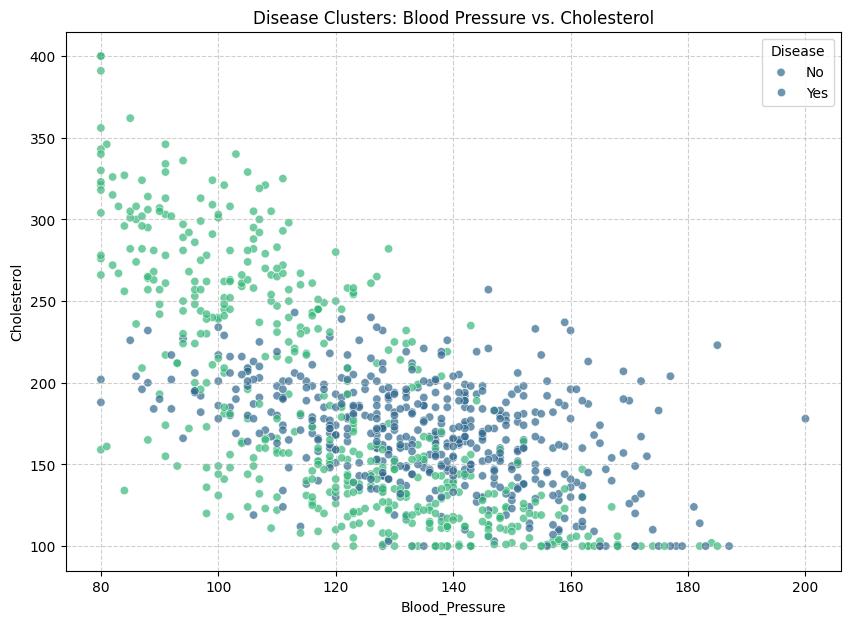

In [15]:
feature_names = df.columns[:-1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=x[:, df.columns.get_loc('Blood_Pressure')],
    y=x[:, df.columns.get_loc('Cholesterol')],
    hue=y,
    palette='viridis',
    alpha=0.7
)
plt.title('Disease Clusters: Blood Pressure vs. Cholesterol')
plt.xlabel(feature_names[df.columns.get_loc('Blood_Pressure')])
plt.ylabel(feature_names[df.columns.get_loc('Cholesterol')])
plt.legend(title='Disease', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Initialize KMeans with 2 clusters (assuming two primary groupings: diseased vs. non-diseased)
# We'll use a fixed random_state for reproducibility
kmeans = KMeans(n_clusters=2, random_state=90, n_init=10)

# Fit KMeans to the feature data (x) and get cluster assignments
clusters = kmeans.fit_predict(x)

print("Cluster assignments generated.")

Cluster assignments generated.


In [17]:
# Apply PCA to reduce the features to 2 dimensions for visualization
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

print("Data reduced to 2 dimensions using PCA.")

Data reduced to 2 dimensions using PCA.


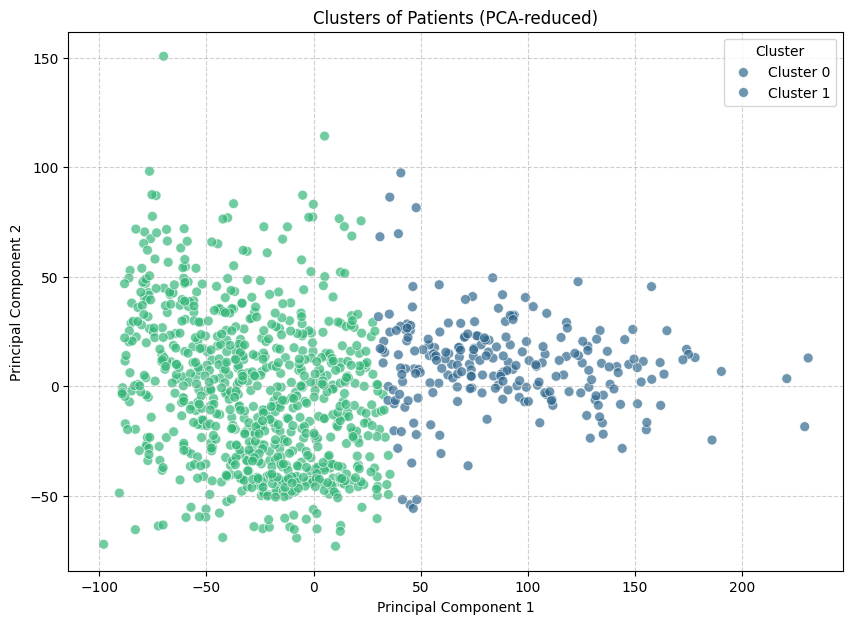

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=clusters, # Color points by the assigned cluster
    palette='viridis',
    alpha=0.7,
    s=50 # Size of the points
)
plt.title('Clusters of Patients (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_5010/2016236830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Disease', data=df, palette='pastel')


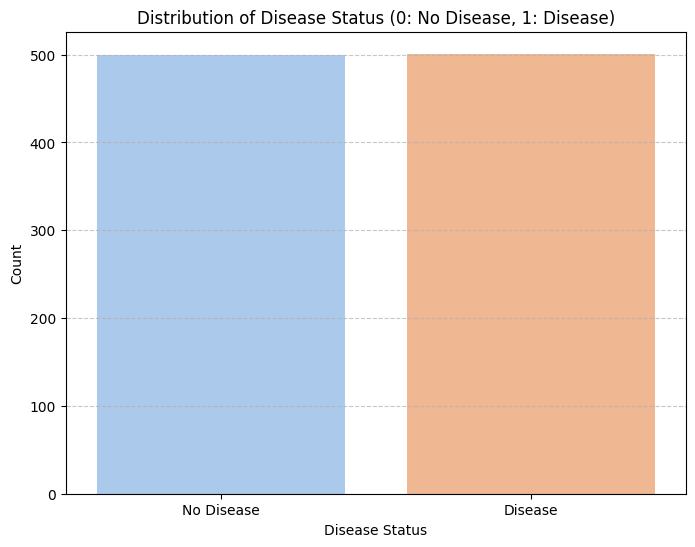

In [19]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Disease', data=df, palette='pastel')
plt.title('Distribution of Disease Status (0: No Disease, 1: Disease)')
plt.xlabel('Disease Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

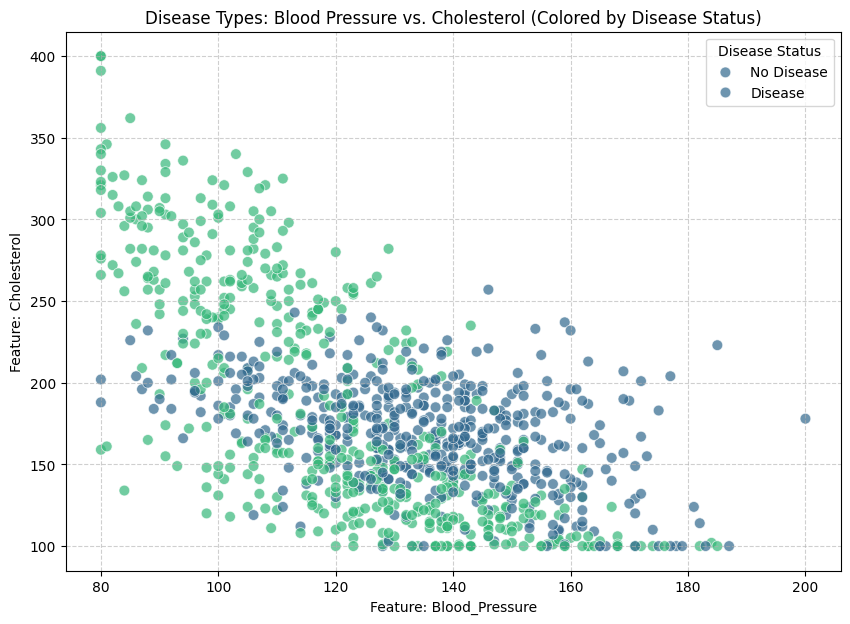

In [20]:
feature_names = df.columns[:-1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=x[:, df.columns.get_loc('Blood_Pressure')],
    y=x[:, df.columns.get_loc('Cholesterol')],
    hue=y, # Use the 'Disease' target variable for coloring
    palette='viridis',
    alpha=0.7,
    s=60 # Increase point size for better visibility
)
plt.title('Disease Types: Blood Pressure vs. Cholesterol (Colored by Disease Status)')
plt.xlabel(f"Feature: {feature_names[df.columns.get_loc('Blood_Pressure')]}")
plt.ylabel(f"Feature: {feature_names[df.columns.get_loc('Cholesterol')]}")
plt.legend(title='Disease Status', labels=['No Disease', 'Disease'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
from sklearn.svm import SVC

# Select the two features for plotting
feature1_idx = df.columns.get_loc('Blood_Pressure')
feature2_idx = df.columns.get_loc('Cholesterol')

x_2d = x[:, [feature1_idx, feature2_idx]]
y_2d = y # The target variable remains the same

# Train a new SVC on these two features
svc_2d = SVC(kernel='linear', random_state=90, probability=True)
svc_2d.fit(x_2d, y_2d)

print("SVC model trained on 'Blood_Pressure' and 'Cholesterol'.")

SVC model trained on 'Blood_Pressure' and 'Cholesterol'.


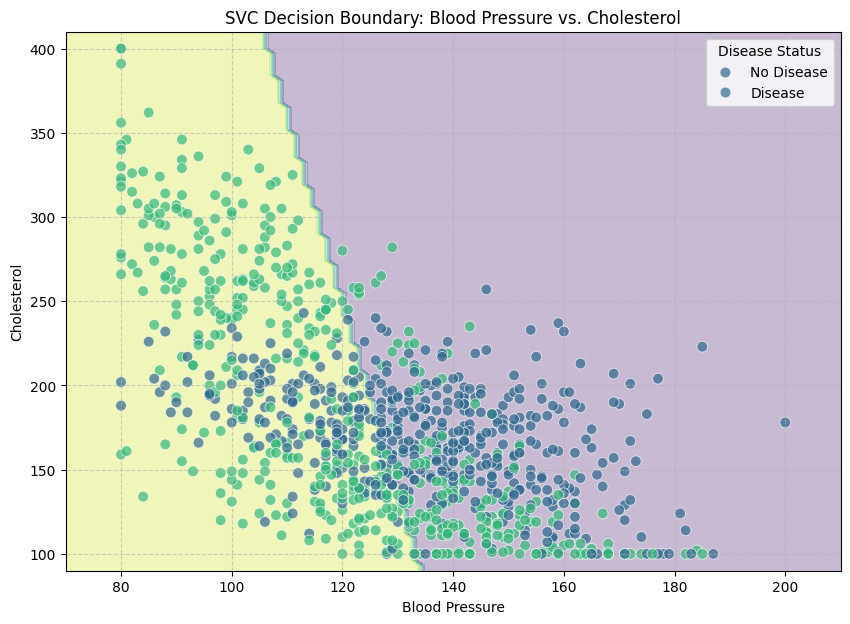

In [22]:
plt.figure(figsize=(10, 7))

# Define the limits for the plot based on the two features
x_min, x_max = x_2d[:, 0].min() - 10, x_2d[:, 0].max() + 10
y_min, y_max = x_2d[:, 1].min() - 10, x_2d[:, 1].max() + 10

# Create a meshgrid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict the class for each point in the meshgrid
Z = svc_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot the original data points, colored by actual disease status
sns.scatterplot(
    x=x_2d[:, 0],
    y=x_2d[:, 1],
    hue=y_2d,
    palette='viridis',
    alpha=0.7,
    s=60
)

plt.title('SVC Decision Boundary: Blood Pressure vs. Cholesterol')
plt.xlabel(f"Blood Pressure")
plt.ylabel(f"Cholesterol")
plt.legend(title='Disease Status', labels=['No Disease', 'Disease'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()